### Visualization Module(5th in operation order):

Description: Intended to be used separately after running data through other modules; asks for the location of data for one (already
processed) observation and plots everything from the variability and spectral analysis modules.


### Expected Results:

Returns the following for each source in “sources.reg”:

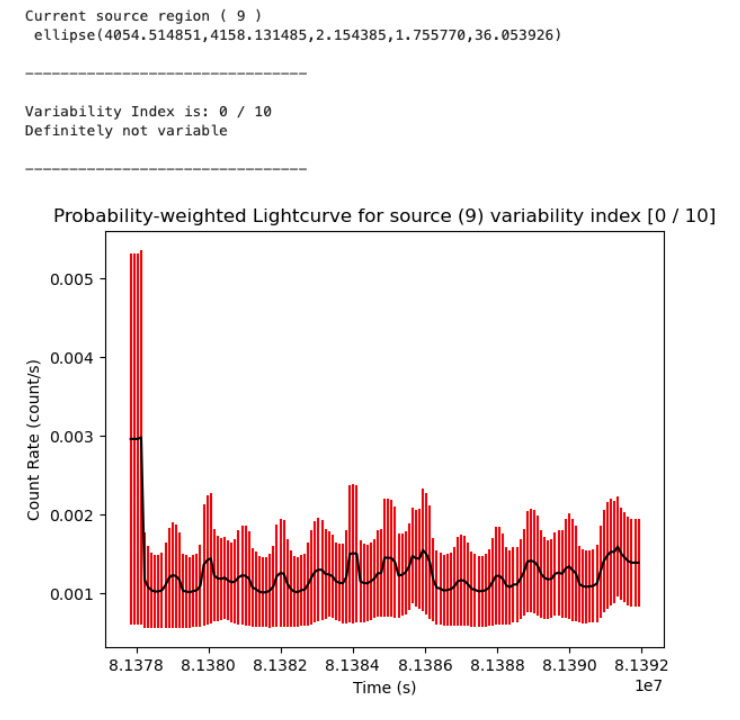

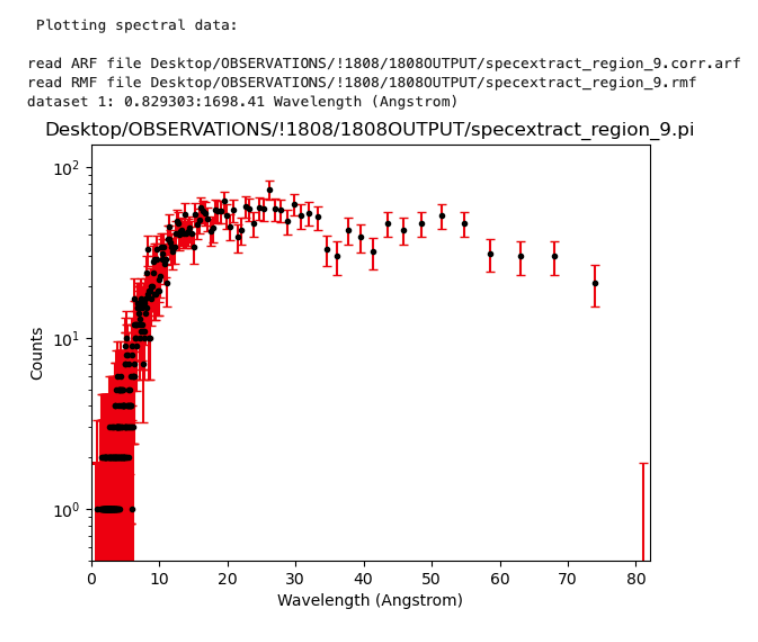

The variability index comes from a table in this (https://cxc.cfa.harvard.edu/ciao/threads/variable/) ciao thread.

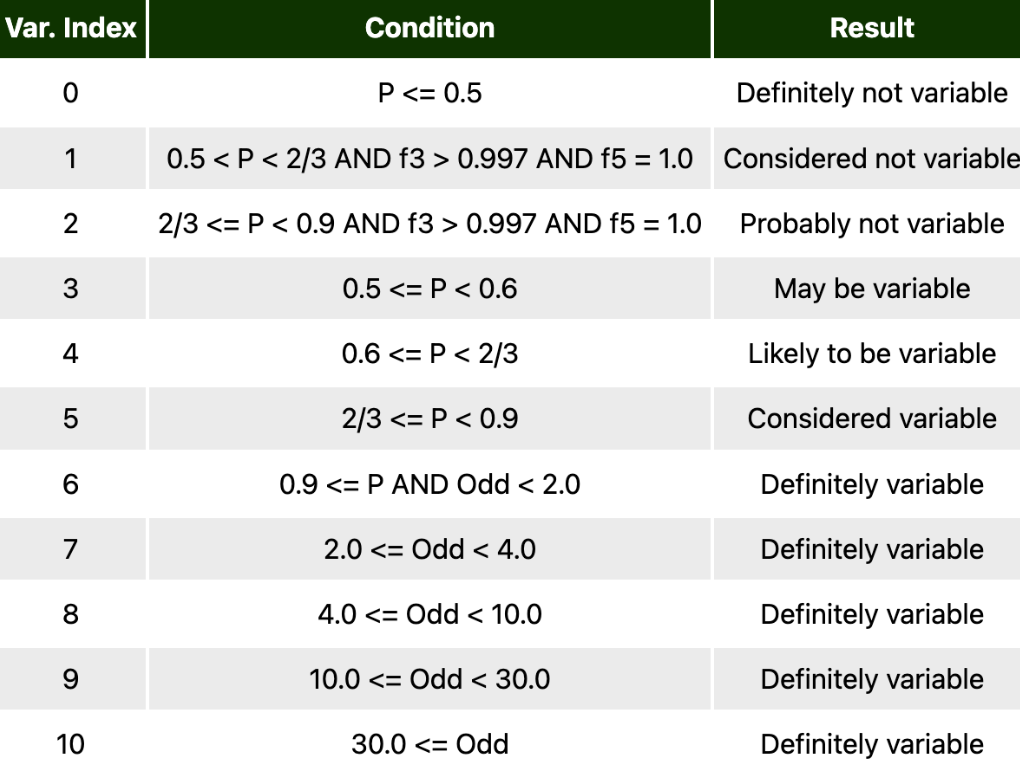

### Code:

In [ ]:
#This module does the following:
#Reads in and displays source regions, variability, and spectral data from an output folder.

#Import modules:

from ciao_contrib import runtool as rt
from subprocess import *
import os
from pathlib import Path
from os import listdir
from os.path import isfile, join
from lightcurves import *
from paramio import *
import paramio
from pycrates import read_file
from astropy.io import fits

#This is a bandaid fix needed to clear any previous plots and fix some issues with matplotlib. Remove if matplotlib isn’t causing any issues.
%matplotlib inline 
import matplotlib.pyplot as plt
plt.clf()

from sherpa.astro.ui import *
from sherpa_contrib.notebook_plotter import notebook_plotter

#This bandaid fix is used to suppress a warning from astropy whenever opening a .fits file. 
import warnings
from astropy.io.fits.verify import VerifyWarning
warnings.simplefilter('ignore', category=VerifyWarning)

#Define functions:

#Returns a string describing how likely a source is to be variable, depending on the variability index.
#https://cxc.cfa.harvard.edu/ciao/threads/variable/
def variability_index_description(index): 
    print("\n--------------------------------\n") #Filler line to make the variability description stand out more than the rest of the text output.
    print("Variability Index is:", index, "/ 10") 
    
    if index==0:
        print("Definitely not variable")
    if index==1:
        print("Considered not variable")
    if index==2:
        print("Probably not variable")    
    if index==3:
        print("May be variable")
    if index==4:
        print("Likely to be variable")
    if index==5:
        print("!Considered variable!")
    if index>5:
        print("!!!Definitely variable!!!")
        
    print("\n--------------------------------\n")

#Set variables:

outputDataFolderPath = ""
outputDataFolderPath = input("Path of OUTPUT folder to read data from:")

fileNamesList = [file for file in listdir(outputDataFolderPath) if isfile(join(outputDataFolderPath, file))]
filePathsList = [outputDataFolderPath+"/"+fileName for fileName in fileNamesList]

regionList = []
regionString = ""

physicalRegFileLocation = outputDataFolderPath+"/sources.reg"
inputEventFile = ""

regionAndVarList = []
varList = []
idList = []

eventFileFound = False
FILE_END_STRING = "evt2"
FITS_FILE_EXTENSION = ".fits"

#Finding the event, or "evt2.fits" file within the output folder:

#Looking for "evt2" AND ".fits" in filenames:
for file in filePathsList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        inputEventFile = file
        eventFileFound = True
        
        print("Event file located at:", inputEventFile)
        break

#NOTE: This error handling code will fail to occur if the flag "eventFileFound" is not reset before running this part of the code.

if eventFileFound == False:
    print("\nOutput folder", outputDataFolderPath, "\ndoes not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")
    raise SystemExit("Output folder", outputDataFolderPath, "does not contain an event file ending in", FILE_END_STRING+FITS_FILE_EXTENSION, "OR the event file was renamed.")


#Make a list of regions from the output region file:
#NOTE: Each of the regions in this list represents a potential source.

with open(physicalRegFileLocation, "r", encoding="utf-8") as file:
    content = file.read()

#This script, which reads the physical region file, needs to skip over the text included at the beginning of the region file. To do this, the code will wait until the string "cal" appears, as "c", "a", and "l" are the last three characters in the word "physical", and physical is the last word that appears at the end of this starting string, which we want to skip over. When reaching this end of the starting string, the code that checks for region syntax will begin to function and read the list of regions from the region file.

currentChar = "None"
previousChar = "None"
previousPreviousChar = "None"
readingRegions = 0

for i in content:

    if readingRegions == 1:
        if i == "\n" or i == " " or i == "#":
            pass
        else:
            regionString = regionString+i

        if i == ")":
            #print(regionString)
            regionList.append(regionString)
            regionString = ""
    else:
        previousPreviousChar = previousChar
        previousChar = currentChar
        currentChar = i
        if currentChar == "l" and previousChar == "a" and previousPreviousChar == "c":
            readingRegions = 1

#Remove any source regions(from the variable "regionList"(used in other modules), not the actual "sources.reg" file) with an area of zero, OR with zero counts; this is to prevent errors in future modules.

print("\nRemoving invalid regions(<1 min)")

i = 1
regionsRemoved = 0
while i <= len(regionList):
    
    currentRegion = regionList[i-1]

    #Check if the region has a radius of zero; this could accidentally flag other strings that have another value (not the radius) that happens to also be exactly zero, but the odds of this happening are low. This code should be removed or replaced as it WILL flag and remove otherwise valid sources in large enough source lists.
    if ",0.000000" in currentRegion:
        print("Source region (", i+regionsRemoved, ") has a radius of zero, removing from regionList")
        regionList.pop(i-1)
        regionsRemoved+=1
        i-=1

    #Checking if each source has a count value above zero (i.e. the region isn't outside the image):

    dmExtractOutfile = outputDataFolderPath+"/count_check.fits"
    dmExtractInfile = inputEventFile+"[bin sky="+currentRegion+"]"

    call(["punlearn", "dmextract"])
    pset ("dmextract", "opt", "generic")
    pset ("dmextract", "clobber", "yes")

    call(["dmextract", dmExtractInfile, dmExtractOutfile])

    HDUList = fits.open(dmExtractOutfile) #Open .fits file, save data as an HDUList object,
    data = HDUList[1].data #Index 1 is where counts info is,
    HDUList.close() #Close the HDUList.

    regionCounts = data[0][15] #This is where the net counts data is.

    if regionCounts == 0:
        print("Source region (", i+regionsRemoved, ") has a net counts of zero, removing from regionList")
        regionList.pop(i-1)
        regionsRemoved+=1
        i-=1

    i+=1

print("\n", len(regionList), "potential sources found:")

for region in regionList:
    print(region)

#Locating every source region file:

FILE_END_STRING = "source_id"
FITS_FILE_EXTENSION = ".reg"

for file in fileNamesList:
    
    if FILE_END_STRING in file and FITS_FILE_EXTENSION in file:
        regionAndVarList.append(file)

        #This gets the variability index from the file name:
        
        if file[-6] == "_":
            varList.append(file[-5])
        else:
            varList.append(join(file[-6], file[-5]))

        #This gets the source ID from the file name:
        
        if file[12] == "i":
            id = file[10]
            idList.append(id)
        elif file[12] == "_":
            id = join(file[10], file[11])
            id = id[0] + id[2]
            idList.append(id)
        else:
            id = join(join(file[10], file[11]), file[12])
            id = id[0]+id[2]+id[4]      
            idList.append(id)

#Loop through each source region,
#Plot the lightcurve + spectral data:

print("Checking variability and spectra for", len(regionList), "sources:\n")
i = 1
while i <= len(regionList):
    currentRegion = regionList[int(idList[i-1])-1]
    print("\nCurrent source region (", idList[i-1], ")\n", currentRegion)
    variability_index_description(int(varList[i-1])) #Calling this function to print a string describing the variability of the source. 
    
    #Make the plot of the probability-weighted lightcurve:

    variabilityOutroot = outputDataFolderPath+"/lc_prob"+str(idList[i-1])+".fits"
    
    tab = read_file(variabilityOutroot)
    xx = tab.get_column("Time").values
    yy = tab.get_column("COUNT_RATE").values
    ye = tab.get_column("COUNT_RATE_ERR").values
    plotTitle = "Probability-weighted Lightcurve for source ("+str(idList[i-1])+") variability index ["+str(varList[i-1])+" / 10]"
        
    plt.xlabel("Time (s)")
    plt.ylabel("Count Rate (count/s)")
    plt.title(plotTitle)
        
    plt.errorbar(xx,yy,yerr=ye, ecolor="red", color="black")
    plt.show()

    #Check if spectra exists for the current source, then load spectra data and plot it:

    specextractOutroot = outputDataFolderPath+"/specextract_region_"+str(idList[i-1])
    
    if Path(specextractOutroot+".pi").exists():
        
        print("\n", "Plotting spectral data:", "\n")
    
        load_pha(1, specextractOutroot+".pi")
        load_arf(1, specextractOutroot+".corr.arf")
        load_rmf(1, specextractOutroot+".rmf")
        set_analysis(1, 'wave', 'counts')
    
        plot_data(yerrorbars=True, capsize=3, ecolor="red", color="black", xlog=False, ylog=True)
        plt.xlim(0, 82)
        plt.ylim(0.5, 135)
        plt.show()
    
    print("\n")
    
    i+=1
